Para resolver estos límites de manera automatizada y visual, podemos construir una función que combine el poder simbólico de **SymPy** con la visualización de **Pandas**, **Matplotlib** y **Plotly**.

Aquí tienes el código necesario. Asegúrate de tener instaladas las librerías: `pip install sympy pandas matplotlib plotly`.



In [1]:
import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt
import plotly.graph_objects as go

def analizar_limite(f_expr, direccion="inf"):
    """
    Analiza un límite de forma simbólica, tabular y gráfica.
    
    Args:
        f_expr: Expresión de SymPy (ej: (3*x**2 - 8*x + 7) / (5*x**2 - 2*x + 5))
        direccion: "inf" o "-inf"
    """
    x = sp.Symbol('x')
    
    # 1. Cálculo Simbólico con SymPy
    limite_valor = sp.limit(f_expr, x, sp.oo if direccion == "inf" else -sp.oo)
    print(f"--- Análisis para x -> {direccion} ---")
    print(f"Valor del límite (SymPy): {limite_valor}\n")

    # 2. Análisis Tabular con Pandas
    # Generamos valores que se acerquen al infinito
    if direccion == "inf":
        valores_x = [10, 100, 1000, 10000, 100000]
    else:
        valores_x = [-10, -100, -1000, -10000, -100000]
    
    f_num = sp.lambdify(x, f_expr, 'numpy')
    df = pd.DataFrame({
        'x': valores_x,
        'f(x)': [float(f_num(val)) for val in valores_x]
    })
    print("Aproximación Tabular:")
    print(df.to_string(index=False))
    print("-" * 40)

    # 3. Visualización Gráfica (Matplotlib)
    x_plot = np.linspace(1, 100, 400) if direccion == "inf" else np.linspace(-100, -1, 400)
    y_plot = f_num(x_plot)
    
    plt.figure(figsize=(10, 4))
    plt.plot(x_plot, y_plot, label=f'$f(x) = {sp.latex(f_expr)}$')
    plt.axhline(y=float(limite_valor), color='r', linestyle='--', label=f'Límite = {limite_valor}')
    plt.title(f"Comportamiento de la función hacia {direccion}")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.legend()
    plt.grid(True)
    plt.savefig(r"C:\Users\marco\Downloads\limite_grafico_matplotlib.png")  # Guardar la imagen del gráfico
    plt.show()

    # 4. Visualización Interactiva (Plotly)
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=x_plot, y=y_plot, mode='lines', name='f(x)'))
    fig.add_hline(y=float(limite_valor), line_dash="dash", line_color="red",\
        annotation_text="Límite")
    fig.update_layout(title=f"Gráfico Interactivo x -> {direccion}", \
        xaxis_title="x", yaxis_title="f(x)")
    fig.write_image(r"C:\Users\marco\Downloads\limite_grafico.png")  # Guardar la imagen del gráfico
    fig.show()


EJERCICIO (a)
--- Análisis para x -> inf ---
Valor del límite (SymPy): 3/5

Aproximación Tabular:
     x     f(x)
    10 0.468041
   100 0.586427
  1000 0.598640
 10000 0.599864
100000 0.599986
----------------------------------------


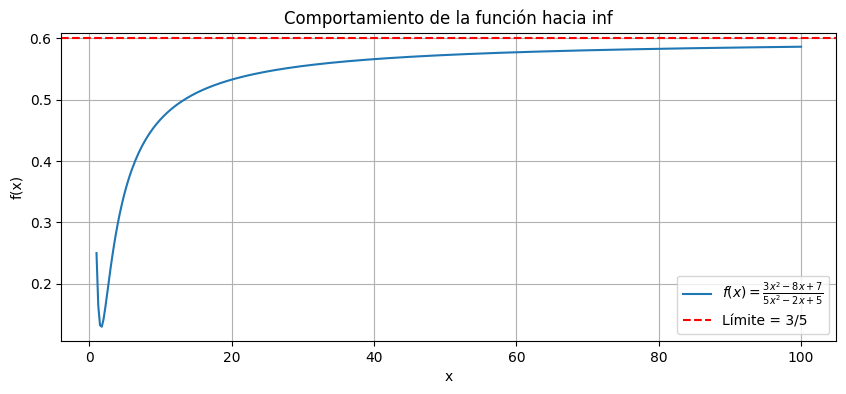

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [2]:

# --- EJECUCIÓN DE LOS EJERCICIOS DE LA IMAGEN ---
x = sp.Symbol('x')

# (a)
print("EJERCICIO (a)")
f_a = (3*x**2 - 8*x + 7) / (5*x**2 - 2*x + 5)
analizar_limite(f_a, "inf")


In [ ]:

# (b)
print("\nEJERCICIO (b)")
f_b = (2*x + 3) / (3*x**2 - 5*x + 8)
analizar_limite(f_b, "inf")

# (c)
print("\nEJERCICIO (c)")
f_c = (3*x - 8) / (x + 2)
analizar_limite(f_c, "-inf")

# (d)
print("\nEJERCICIO (d)")
f_d = 2*x - sp.sqrt(4*x**2 - 5*x)
analizar_limite(f_d, "-inf")



# Explicación de los resultados esperados:

Para que puedas validar lo que el código arrojará, aquí tienes la resolución teórica rápida:

* **Límite (a):** Al tener el mismo grado en numerador y denominador ($x^2$), el límite es el cociente de los coeficientes principales: **$3/5$**.
* **Límite (b):** El grado del denominador ($x^2$) es mayor que el del numerador ($x$), por lo tanto, el límite es **$0$**.
* **Límite (c):** Al tender a $-\infty$ con grados iguales ($x$), el límite es el cociente de los coeficientes: **$3$**.
* **Límite (d):** Este es un caso de indeterminación $\infty - \infty$. Al analizar $x \to -\infty$, hay que tener cuidado con la raíz.
* Simbólicamente: $\lim_{x \to -\infty} (2x - \sqrt{4x^2 - 5x}) = -\infty$.
* *Nota:* Como $x$ es negativo, $2x$ es muy negativo y la raíz siempre devuelve un valor positivo (que se resta), por lo que ambos términos empujan la función hacia el infinito negativo.